# Machine Learning: Volatility Forecasting

## Introduction
prob, sol, methods, imple

### Imports

In [28]:
import src.paths as paths
import src.volatility as volatility
import src.machine_learning as ml
import src.feature_engineering as fe
from src.data import load_data
import run_updates

from arch import arch_model
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

import importlib
importlib.reload(ml)

<module 'src.machine_learning' from 'c:\\Users\\jspit\\OneDrive\\Documents\\personal projects\\Machine Learning Fin\\src\\machine_learning.py'>

# Data

Daily OHLCV data is obtained from yfinance and FRED, and is used to construct the volatility target and endogenous features. VIX is incorporated as an exogneous measure of overall market volatility.

The analysis uses BTC.

Data is loaded through the project's data pipeline which handles retrieval, caching, cleaning, and alignment.

Run this first to fetch the latest stock/market data.

In [100]:
run_updates.main()

Loaded and processed: commodities (10 items)
Loaded and processed: crypto (29 items)
Loaded and processed: macro (31 items)
Loaded and processed: equities (15 items)
Loaded and processed: forex (6 items)
Loaded and processed: indices (24 items)
Starting update run...

[commodities]
completed: 10 updated, 0 skipped, 0 failed
saved rows=6722 cols=50 range=2000-01-03 to 2026-09-07

[crypto]
completed: 29 updated, 0 skipped, 0 failed
saved rows=4374 cols=145 range=2014-09-17 to 2026-09-07

[macro]
Unsupported source: Scrape
completed: 30 updated, 1 skipped, 0 failed
saved rows=17686 cols=34 range=1913-01-01 to 2026-09-07

[equities]
completed: 15 updated, 0 skipped, 0 failed
saved rows=16278 cols=75 range=1962-01-02 to 2026-09-04

[forex]
completed: 6 updated, 0 skipped, 0 failed
saved rows=14141 cols=30 range=1971-01-04 to 2026-09-07

[indices]
completed: 24 updated, 0 skipped, 0 failed
saved rows=25305 cols=120 range=1927-12-30 to 2026-09-07

Run complete
updated=114 skipped=1 failed=0
l

Load the data to be used in the analysis

In [2]:
asset = 'BTC'

ohlcv = load_data(paths.CRYPTO_DATA_PARQUET, '1d')
asset_ohlcv = ohlcv[asset].dropna()

asset_ohlcv.tail()

Price,Close,High,Low,Open,Volume
Date,,,,,
2026-09-03,81271.742188,82262.210938,76940.882812,77300.164062,4.050420e+10
2026-09-04,79671.968750,81433.148438,78641.625000,81271.539062,3.750187e+10
2026-09-05,79823.867188,80194.507812,79465.062500,79671.703125,1.855971e+10
2026-09-06,80350.046875,80530.648438,79327.500000,79824.601562,1.939186e+10
2026-09-07,79437.078125,80387.906250,79218.679688,80351.398438,2.298099e+10


# Volatility Target

Parkinson Volatility is used as the target volatility. This measure uses daily high and low prices to incorporate information about intraday variation, providing a better estimate than Realised Absolute Volume which only uses close-to-close prices. Parkinson volatility is a good estimate for 24/7 markets, however it does not account for overnight volatility and price jumps - a weakness when it comes to typical stock market data. To address this, the Yang-Zhang volatility estimator could be implemented for stock market data.

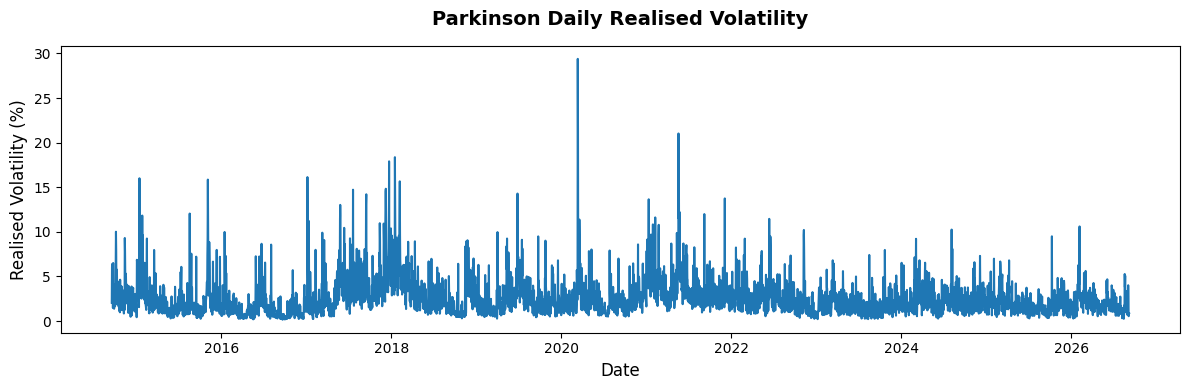

In [3]:
realised_vol = volatility.parkinson_vol(asset_ohlcv)


plt.figure(figsize=(12, 4)) 
plt.plot(realised_vol)
plt.title('Parkinson Daily Realised Volatility', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Realised Volatility (%)', fontsize=12)
plt.tight_layout()
plt.show()


# Volatility Forecast Benchmarks

In [30]:
garch_forecast = volatility.garch_forecast(asset_ohlcv['Close'], 500)
naive_persistent_forecast = volatility.naive_persistent_forecast(realised_vol)
naive_rolling_avg_forecast = volatility.naive_avg_forecast(realised_vol, 21)

forecasts = {
    'GARCH(1,1)': garch_forecast,
    'Naive (persistence)': naive_persistent_forecast,
    'Naive (rolling avg)': naive_rolling_avg_forecast
}

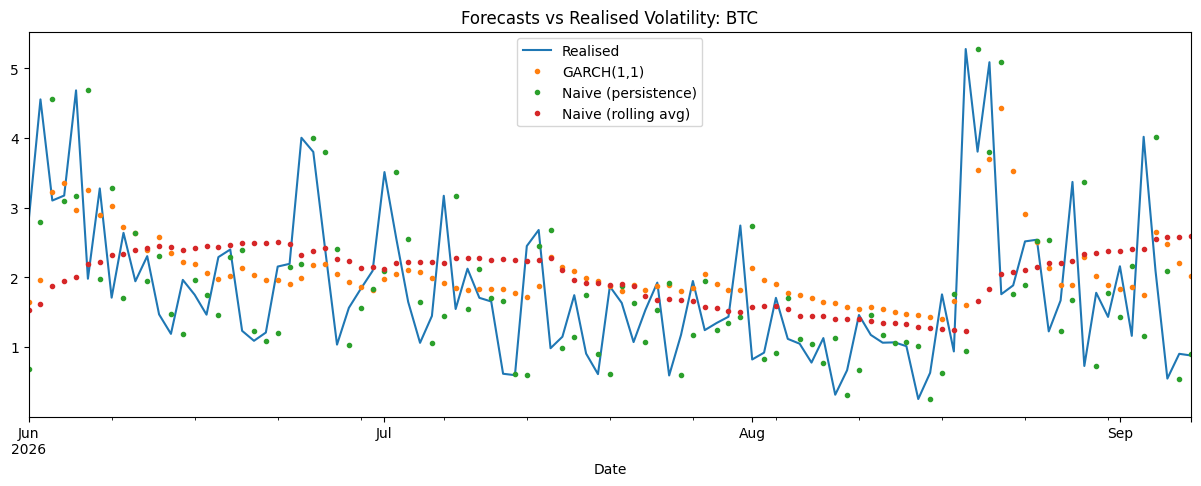

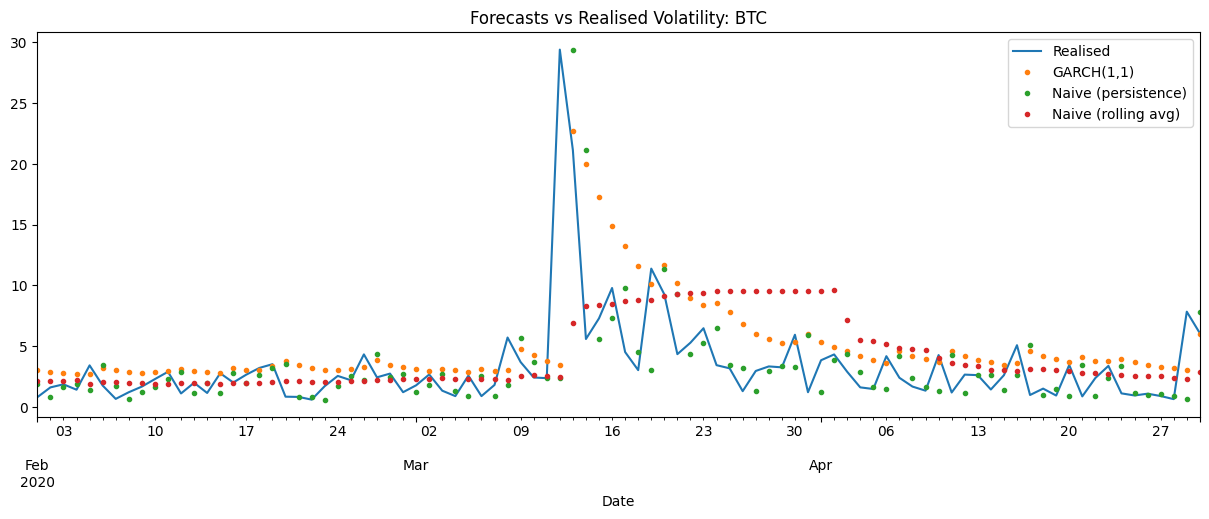

In [38]:
recent = ml.filter_forecasts(forecasts, '2026-06-01', '2026-09-08')
covid = ml.filter_forecasts(forecasts, '2020-02-01', '2020-04-30')

ml.plot_predictions_vs_realised(realised_vol, recent, asset)
ml.plot_predictions_vs_realised(realised_vol, covid, asset)

# Feature Engineering

The model uses both endogenous and exogenous volatility information

## (Lagged) Volatility

## (Lagged) Returns

## Moving Averages

## VIX

In [4]:
features = fe.build_ml_features(asset_ohlcv)

features.tail()

Price,Close,High,Low,Open,Volume,Parkinson,VIX_0,Realised_vol_0,Returns_0,VIX_1,...,Price_vs_sma21,Price_vs_sma50,Price_vs_sma200,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
Date,,,,,,,,,,,,,,,,,,,,,
2026-09-03,81271.742188,82262.210938,76940.882812,77300.164062,4.050420e+10,4.016221,15.20,1.161677,-0.001333,16.34,...,1.039108,1.100156,1.068717,3,3,9,2026,246,3,36
2026-09-04,79671.968750,81433.148438,78641.625000,81271.539062,3.750187e+10,2.094834,14.32,4.016221,0.050098,15.20,...,1.083383,1.149612,1.122242,4,3,9,2026,247,4,36
2026-09-05,79823.867188,80194.507812,79465.062500,79671.703125,1.855971e+10,0.548767,14.53,2.094834,-0.019881,14.32,...,1.056099,1.121399,1.099056,5,3,9,2026,248,5,36
2026-09-06,80350.046875,80530.648438,79327.500000,79824.601562,1.939186e+10,0.904024,14.53,0.548767,0.001905,14.53,...,1.052552,1.118120,1.100044,6,3,9,2026,249,6,36
2026-09-07,79437.078125,80387.906250,79218.679688,80351.398438,2.298099e+10,0.879919,14.53,0.904024,0.006570,14.53,...,1.053791,1.119979,1.106115,0,3,9,2026,250,7,37


In [5]:
features.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Parkinson', 'VIX_0',
       'Realised_vol_0', 'Returns_0', 'VIX_1', 'Realised_vol_1', 'Returns_1',
       'VIX_2', 'Realised_vol_2', 'Returns_2', 'VIX_5', 'Realised_vol_5',
       'Returns_5', 'VIX_10', 'Realised_vol_10', 'Returns_10', 'VIX_20',
       'Realised_vol_20', 'Returns_20', 'VIX_60', 'Realised_vol_60',
       'Returns_60', 'VIX_120', 'Realised_vol_120', 'Returns_120', 'Vol_7_sma',
       'Vol_7_ema', 'Price_7_sma', 'Price_7_ema', 'Vol_14_sma', 'Vol_14_ema',
       'Price_14_sma', 'Price_14_ema', 'Vol_21_sma', 'Vol_21_ema',
       'Price_21_sma', 'Price_21_ema', 'Vol_50_sma', 'Vol_50_ema',
       'Price_50_sma', 'Price_50_ema', 'Vol_200_sma', 'Vol_200_ema',
       'Price_200_sma', 'Price_200_ema', 'Price_vs_sma7', 'Price_vs_sma21',
       'Price_vs_sma50', 'Price_vs_sma200', 'dayofweek', 'quarter', 'month',
       'year', 'dayofyear', 'dayofmonth', 'weekofyear'],
      dtype='str', name='Price')

# XGBoost Model

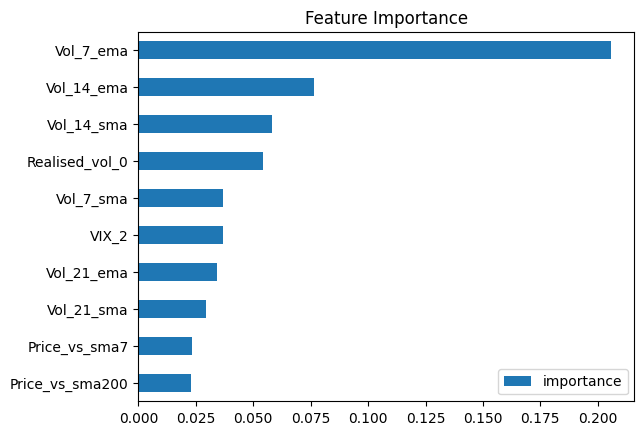

In [6]:
train_data, test_data = ml.split_train_test(features, split_date='2024-01-01')
model = ml.train_model(train_data)

ml.plot_feature_importance(model)


| Parameter | Value | Rationale |
| :--- | :--- | :--- |
| **Max depth** | 3 | Limit model complexity |
| **Learning rate** | 0.01 | Gradual boosting |
| **Estimators** | 1000 | Upper bound with early stopping |
| **Early stopping** | 50 | Prevent unnecessary iterations |


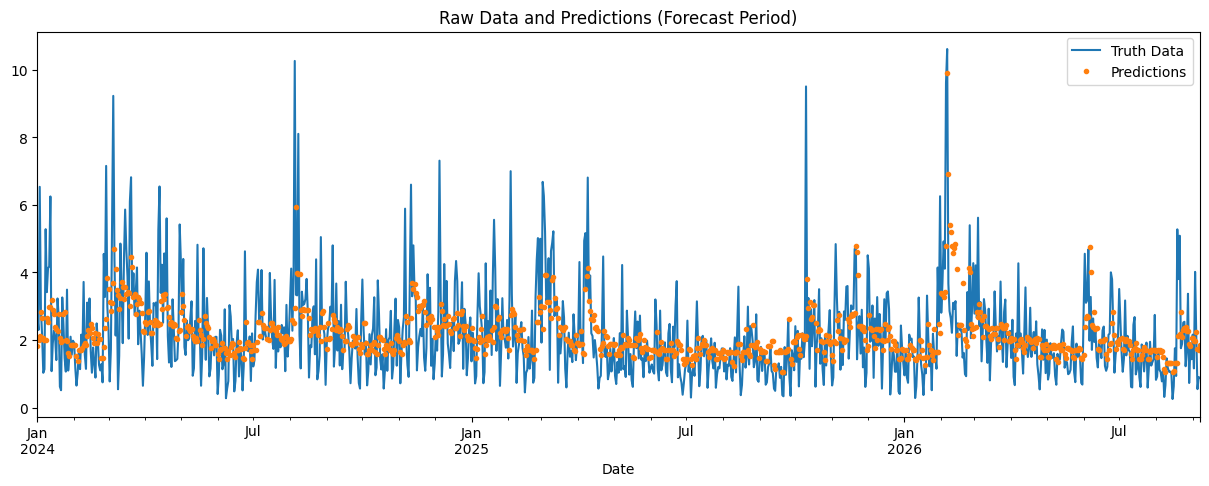

In [7]:
model_forecast = ml.forecast_model(test_data, model)

ml.plot_predictions_vs_realised(model_forecast, features)

In [8]:
forecasts = {
    'GARCH(1,1)': volatility.garch_forecast(asset_ohlcv['Close'], 500),
    'Naive (persistence)': volatility.naive_persistent_forecast(realised_vol),
    'Naive (rolling avg)': volatility.naive_avg_forecast(realised_vol, 500),
    'ML Model': model_forecast,
}

results = ml.compare_forecasts(forecasts, realised_vol)

df = pd.DataFrame(results).T.round(4)
print(df)

                      qlike       mse     mae
GARCH(1,1)           0.5803   91.8788  5.0785
Naive (persistence)  1.2779  135.9429  6.0095
Naive (rolling avg)  0.6785  101.0533  5.5113
ML Model             0.5160   78.9529  4.3930


# Walk-Forward Validation

In [9]:
results_per_block, results_combined, forecasts = ml.run_walk_forward_comparison(asset_ohlcv)

In [11]:
df = pd.DataFrame(results_combined).T.round(4)
print(df)

                          qlike       mse      mae
GARCH(1,1)               0.8022  676.4871  10.8755
Naive (persistence)      1.9165  836.7071  10.4516
Naive (rolling avg)      1.0050  740.9866  11.4983
ML Model (Walk-Forward)  0.8230  654.0728   8.4203


Model   GARCH(1,1)  ML Model  Naive (persistence)  Naive (rolling avg)
mean        0.8062    0.8210               1.9168               1.0072
std         0.3283    0.4500               1.2873               0.4290
median      0.6644    0.6917               1.4601               0.9204
min         0.3831    0.2865               0.6744               0.4055
max         1.5791    2.4293               6.6931               2.0424


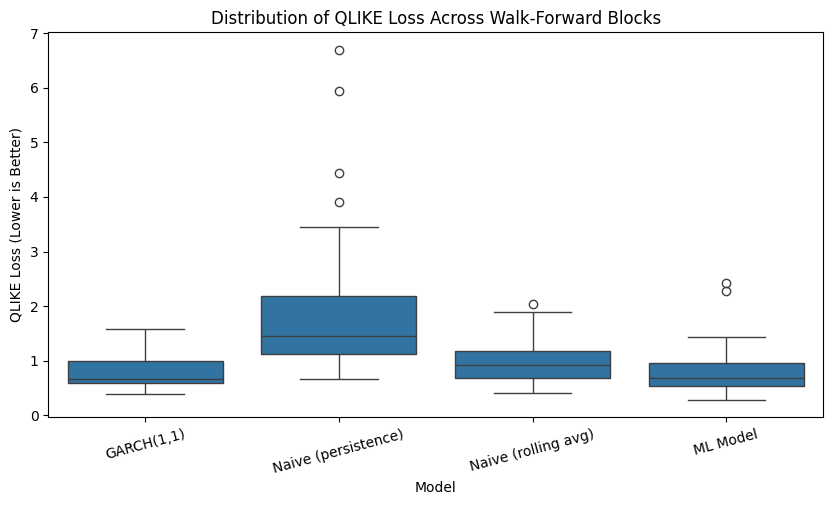

In [12]:
rows = []
for block, models in results_per_block.items():
    for model, metrics in models.items():
        row = {'Block': block, 'Model': model}
        row.update(metrics)
        rows.append(row)

df = pd.DataFrame(rows)

summary_stats = df.groupby('Model')[['qlike', 'mse', 'mae']].agg(['mean', 'std', 'median', 'min', 'max'])
summary_stats = summary_stats.round(4)

print(summary_stats['qlike'].T)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df.reset_index(), x='Model', y='qlike')
plt.title('Distribution of QLIKE Loss Across Walk-Forward Blocks')
plt.ylabel('QLIKE Loss (Lower is Better)')
plt.xticks(rotation=15)
plt.show()


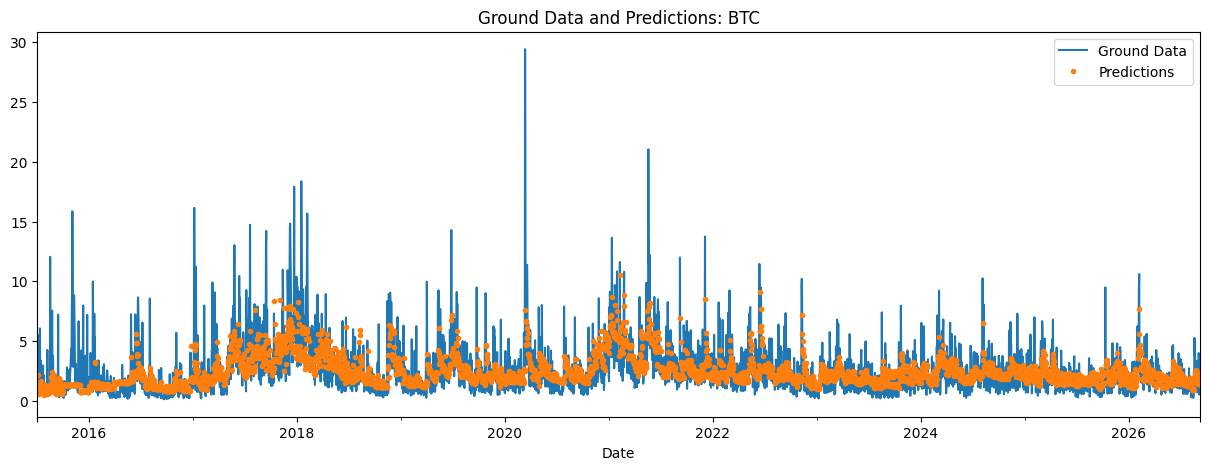

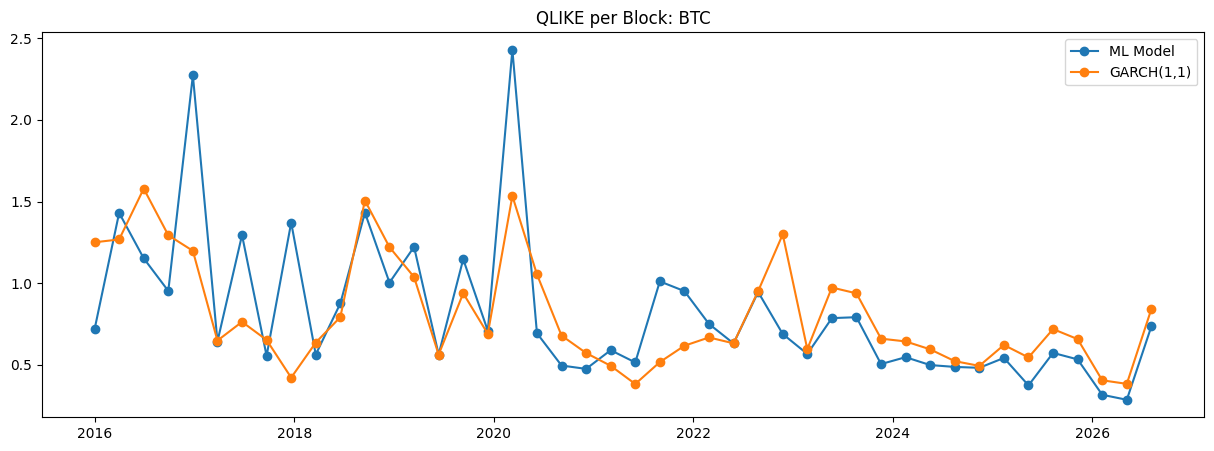

In [13]:
ml.plot_walk_forward(realised_vol, forecasts, results_per_block, asset)